In [10]:
#get Data
#get data from GitHub -> https://github.com/keuperj/DATA
!git clone https://github.com/keuperj/DATA.git

fatal: destination path 'DATA' already exists and is not an empty directory.


# Ex 1.2: A simple parallel MapReduce framework in Python
Now we use the [*multiprocessing*](https://docs.python.org/3/library/multiprocessing.html) lib to actually do things in parallel

In [24]:
import collections
import itertools
import multiprocessing


class SimpleMapReduce:

    def __init__(self, map_func, reduce_func, num_workers=None):
        """
        map_func

          Function to map inputs to intermediate data. Takes as
          argument one input value and returns a tuple with the
          key and a value to be reduced.

        reduce_func

          Function to reduce partitioned version of intermediate
          data to final output. Takes as argument a key as
          produced by map_func and a sequence of the values
          associated with that key.

        num_workers

          The number of workers to create in the pool. Defaults
          to the number of CPUs available on the current host.
        """
        self.map_func = map_func
        self.reduce_func = reduce_func
        self.pool = multiprocessing.Pool(num_workers)

    def partition(self, mapped_values):
        """Organize the mapped values by their key.
        Returns an unsorted sequence of tuples with a key
        and a sequence of values.
        """
        partitioned_data = collections.defaultdict(list)
        for key, value in mapped_values:
            partitioned_data[key].append(value)
        return partitioned_data.items()

    def __call__(self, inputs, chunksize=1):
        """Process the inputs through the map and reduce functions
        given.

        inputs
          An iterable containing the input data to be processed.

        chunksize=1
          The portion of the input data to hand to each worker.
          This can be used to tune performance during the mapping
          phase.
        """
        map_responses = self.pool.map(
            self.map_func,
            inputs,
            chunksize=chunksize,
        )
        # The next line needs to be adjusted based on whether map_func returns a single (key, value)
        # or a list of (key, value) pairs for each input.
        # For file_to_words, map_responses is a list of lists of (key, value) pairs.
        # For kMap, map_responses is a list of (key, value) tuples.
        if isinstance(map_responses[0], list):
            # This path is for when map_func returns a list of (key, value) pairs (e.g., file_to_words)
            partitioned_data = self.partition(
                itertools.chain(*map_responses)
            )
        else:
            # This path is for when map_func returns a single (key, value) tuple (e.g., kMap)
            partitioned_data = self.partition(
                map_responses
            )

        reduced_values = self.pool.map(
            self.reduce_func,
            partitioned_data,
        )
        return reduced_values

### A Word Count example

In [25]:
import string

# map - read file and count words
def file_to_words(filename):
    """Read a file and return a sequence of
    (word, occurences) values.
    """
    STOP_WORDS = set([
        'a', 'an', 'and', 'are', 'as', 'be', 'by', 'for', 'if',
        'in', 'is', 'it', 'of', 'or', 'py', 'rst', 'that', 'the',
        'to', 'with',
    ])
    TR = str.maketrans({
        p: ' '
        for p in string.punctuation
    })

    print('{} reading {}'.format(
        multiprocessing.current_process().name, filename))
    output = []

    with open(filename, 'rt') as f:
        for line in f:
            # Skip comment lines.
            if line.lstrip().startswith('..'):
                continue
            line = line.translate(TR)  # Strip punctuation
            for word in line.split():
                word = word.lower()
                if word.isalpha() and word not in STOP_WORDS:
                    output.append((word, 1))
    return output

# reduce
def count_words(item):
    """Convert the partitioned data for a word to a
    tuple containing the word and the number of occurences.
    """
    word, occurences = item
    return (word, sum(occurences))

In [26]:
import operator
import glob #easy file access

input_files = glob.glob('DATA/*.rst')#get all text files names

mapper = SimpleMapReduce(file_to_words, count_words)#get mapreduce instance with custom map and reduce functions
word_counts = mapper(input_files)#call parallel mapreduce on files

word_counts.sort(key=operator.itemgetter(1))#sort results
word_counts.reverse()

print('\nTOP 20 WORDS BY FREQUENCY\n')
top20 = word_counts[:20]
longest = max(len(word) for word, count in top20)
for word, count in top20:
    print('{word:<{len}}: {count:5}'.format(
            len=longest + 1,
            word=word,
            count=count)
    )

ForkPoolWorker-8 reading DATA/text2.rstForkPoolWorker-7 reading DATA/text4.rst

ForkPoolWorker-7 reading DATA/text1.rstForkPoolWorker-8 reading DATA/text3.rst


TOP 20 WORDS BY FREQUENCY

my    :    67
i     :    60
her   :    43
he    :    41
quiz  :    33
quick :    28
was   :    28
his   :    23
fox   :    22
she   :    21
from  :    20
when  :    20
blind :    19
vex   :    18
would :    18
so    :    18
have  :    18
but   :    18
on    :    17
big   :    16


## K-Means implementation
Use the simple frame work to implement K-Means

In [27]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

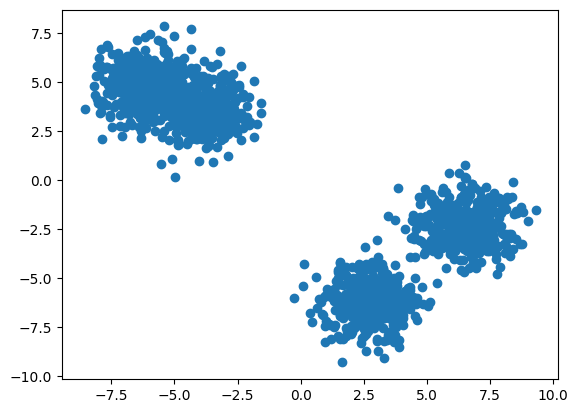

In [28]:
#generate data with K=4
X, y = make_blobs(n_samples=1500, centers=4)
plt.scatter(X[:, 0], X[:, 1])

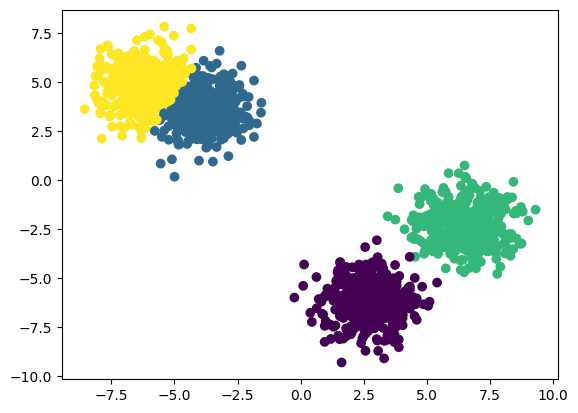

In [29]:
#K-Means ref implementation
k = KMeans(n_clusters=4, random_state=42)
y_pred = k.fit_predict(X)

plt.scatter(X[:, 0], X[:, 1], c=y_pred)

In [30]:
k.cluster_centers_

array([[ 2.73525291, -6.17274984],
       [-3.82847344,  3.58044421],
       [ 6.57153365, -2.28248629],
       [-6.2199593 ,  4.84634034]])

In [31]:
import numpy as np

#implement map -> assign data to center
def kMap(x):
    """Assign a data point to the closest cluster center.
    Returns a tuple with the cluster index (key) and the data point (value).
    """
    # 'centers' must be globally available or passed as an argument
    distances = np.linalg.norm(centers - x, axis=1)
    closest_center_index = np.argmin(distances)
    return (closest_center_index, x)

In [32]:
#implement reduce -> compute new centers
def kReduce(item):
    """Compute the new center for a cluster.
    Takes a tuple with the cluster index (key) and a sequence of data points (values).
    Returns a tuple with the cluster index (key) and the new center (value).
    """
    cluster_index, data_points = item
    new_center = np.mean(data_points, axis=0)
    return (cluster_index, new_center)

In [33]:
#init centers
centers = X[np.random.randint(X.shape[0], size=4), :]#get 4 random datapoints
print('Initial centers:\n', centers)

Initial centers:
 [[ 2.49861369 -7.93591153]
 [-5.47963433  5.24730361]
 [-5.05207303  3.99872184]
 [-4.10290384  2.97908733]]



Iteration 1:
Current centers:
 [[ 4.64827824 -4.23280508]
 [-6.13203311  5.30636585]
 [-5.31641398  3.95859381]
 [-3.58819249  3.21128606]]

Iteration 2:
Converged after 2 iterations.

Final centers found by SimpleMapReduce K-Means:
 [[ 4.64827824 -4.23280508]
 [-6.13203311  5.30636585]
 [-5.31641398  3.95859381]
 [-3.58819249  3.21128606]]


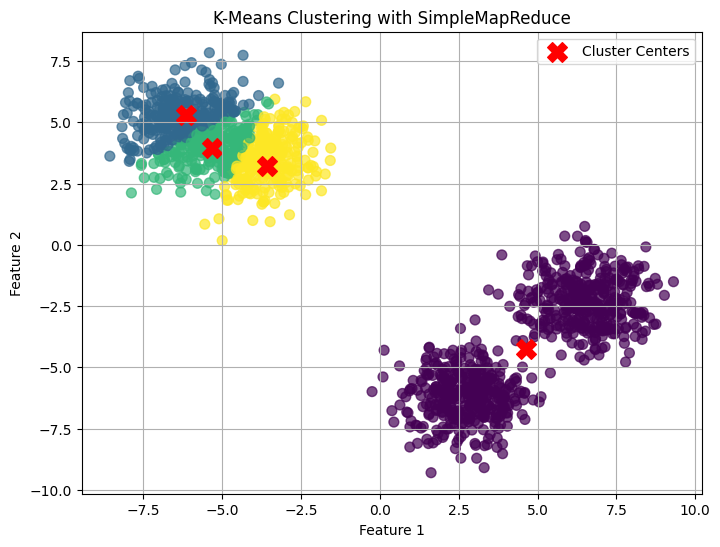

In [34]:
#use framework
mapper = SimpleMapReduce(kMap, kReduce) # get mapreduce instance with custom map and reduce functions

# K-Means iterations
max_iterations = 10
for i in range(max_iterations):
    print(f"\nIteration {i+1}:")
    # Perform map-reduce step to assign points to clusters and re-calculate centers
    new_centers_list = mapper(X)

    # Sort new_centers_list by cluster index to ensure consistent order
    new_centers_list.sort(key=lambda x: x[0])

    # Extract just the center coordinates
    new_centers = np.array([center_coords for index, center_coords in new_centers_list])

    # Check for convergence
    if np.allclose(centers, new_centers):
        print(f"Converged after {i+1} iterations.")
        break

    centers = new_centers
    print('Current centers:\n', centers)

print('\nFinal centers found by SimpleMapReduce K-Means:\n', centers)

# Assign each point to its final cluster to visualize
assigned_clusters = [kMap(point)[0] for point in X]

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=assigned_clusters, cmap='viridis', s=50, alpha=0.7)
plt.scatter(centers[:, 0], centers[:, 1], marker='X', s=200, c='red', label='Cluster Centers')
plt.title('K-Means Clustering with SimpleMapReduce')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()